# **Library and Data import**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import pickle
import warnings
warnings.filterwarnings('ignore')

In [6]:
data = pd.read_csv('/content/online_retail_II.csv')
df = pd.DataFrame(data)
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


# **Exploratory Data Analysis**

**1.1 Overview**

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [11]:
#Total missing values
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

There are significant missing values in two columns Description and CustomerID. Since these information affects product analysis and customer behaviour analysis directly, proper missing values handling is necessary. Possible solutions for handling missing values

*   Description column: Check the StockCode to map products, then fill the Description column with mapped products. Mark null products that can not be mapped as 'Unknown'.
*   Customer ID column: Dropping null values although the missing proportion is ~20% of the dataset. This is due to the ultimate goal of customer segmentation, unknown customers can be distorted



In [21]:
#Total duplicates
total_duplicates = df.duplicated().sum()
print(f"Total number of duplicate rows: {total_duplicates}")

Total number of duplicate rows: 34335


In [14]:
#Distribution of numeric attributes
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


From the five-number summary above of two numerical columns Quantity and Price, there are significant negative values in both columns. These negative values may derive from refund and return orders.

In [24]:
df.sort_values(by=['Invoice', 'InvoiceDate'])
print(df[df['Quantity'] < 0][['Invoice', 'InvoiceDate', 'Quantity']])

         Invoice          InvoiceDate  Quantity
178      C489449  2009-12-01 10:33:00       -12
179      C489449  2009-12-01 10:33:00        -6
180      C489449  2009-12-01 10:33:00        -4
181      C489449  2009-12-01 10:33:00        -6
182      C489449  2009-12-01 10:33:00       -12
...          ...                  ...       ...
1065910  C581490  2011-12-09 09:57:00       -11
1067002  C581499  2011-12-09 10:28:00        -1
1067176  C581568  2011-12-09 11:57:00        -5
1067177  C581569  2011-12-09 11:58:00        -1
1067178  C581569  2011-12-09 11:58:00        -5

[22950 rows x 3 columns]


In [25]:
negative_transactions_no_C = df[(df['Quantity'] < 0) & (~df['Invoice'].str.startswith('C'))]
print(negative_transactions_no_C['Invoice'].unique())
total_quantity = negative_transactions_no_C['Quantity'].count()
print(total_quantity)
print(negative_transactions_no_C)

<ArrowStringArray>
['489464', '489463', '489467', '489521', '489655', '489660', '489663',
 '489806', '489820', '489821',
 ...
 '581204', '581205', '581206', '581207', '581208', '581210', '581212',
 '581213', '581226', '581422']
Length: 3393, dtype: str
3457
        Invoice StockCode   Description  Quantity          InvoiceDate  Price  \
263      489464     21733  85123a mixed       -96  2009-12-01 10:52:00    0.0   
283      489463     71477         short      -240  2009-12-01 10:52:00    0.0   
284      489467    85123A   21733 mixed      -192  2009-12-01 10:53:00    0.0   
470      489521     21646           NaN       -50  2009-12-01 11:44:00    0.0   
3114     489655     20683           NaN       -44  2009-12-01 17:26:00    0.0   
...         ...       ...           ...       ...                  ...    ...   
1060794  581210     23395         check       -26  2011-12-07 18:36:00    0.0   
1060796  581212     22578          lost     -1050  2011-12-07 18:38:00    0.0   
1060797  5812

There are 3456 rows with negative quantity and price = 0. Looking at the description, these are likely the internal stock adjustments của warehouse, not the real transaction (CustomerID is also null)

In [26]:
negative_transactions = df[df['Quantity'] < 0]
print(negative_transactions['Invoice'].unique())
negative_transactions['Invoice'].str.startswith('C').sum()

<ArrowStringArray>
['C489449', 'C489459',  '489464',  '489463',  '489467', 'C489476', 'C489503',
 'C489504', 'C489518',  '489521',
 ...
 'C581464', 'C581465', 'C581466', 'C581468', 'C581470', 'C581484', 'C581490',
 'C581499', 'C581568', 'C581569']
Length: 11684, dtype: str


np.int64(19493)

There are 19493 negative values, which accounts for around 2% of the dataset, in the Quantity column. These values mostly derive from returned transactions (indicated the invoices that start with letter 'C').  




In [29]:
df.sort_values(by=['Invoice'])
print(df[df['Price'] < 0][['Invoice', 'InvoiceDate', 'Quantity', 'Price']])

        Invoice          InvoiceDate  Quantity     Price
179403  A506401  2010-04-29 13:36:00         1 -53594.36
276274  A516228  2010-07-19 11:24:00         1 -44031.79
403472  A528059  2010-10-20 12:04:00         1 -38925.87
825444  A563186  2011-08-12 14:51:00         1 -11062.06
825445  A563187  2011-08-12 14:52:00         1 -11062.06


Meanwhile, there are only five negative values in the Price column and these are mostly coming from refund products. This can be seen in the invoices that start with letter 'A'.

Since the StockCode is supposed to be a 5-digit integral number, there are some stock codes that do not follow this rule. These may be non-sales items such as gifts, postages, etc.

In [ ]:
stockcodes = df_cleaned[df_cleaned.StockCode.str.match('^\\d{5}[a-zA-Z]*$') == False]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
desc_groupings = stockcodes.groupby('StockCode').first()
for i in stockcodes.StockCode.unique():
    print(f'{i}: {desc_groupings[desc_groupings.index == i].Description.iloc[0]}')

POST: POSTAGE
DCGS0058: MISO PRETTY  GUM
DCGS0068: DOGS NIGHT COLLAR
DOT: DOTCOM POSTAGE
M: Manual
DCGS0004: HAYNES CAMPER SHOULDER BAG
DCGS0076: SUNJAR LED NIGHT NIGHT LIGHT
C2: CARRIAGE
BANK CHARGES:  Bank Charges
DCGS0003: BOXED GLASS ASHTRAY
TEST001: This is a test product.
gift_0001_80: Dotcomgiftshop Gift Voucher £80.00
DCGS0072: CAT CAMOUFLAGUE COLLAR
gift_0001_20: Dotcomgiftshop Gift Voucher £20.00
DCGS0044: HANDZ-OFF CAR FRESHENER
TEST002: This is a test product.
gift_0001_10: Dotcomgiftshop Gift Voucher £10.00
gift_0001_50: Dotcomgiftshop Gift Voucher £50.00
DCGS0066N: NAVY CUDDLES DOG HOODIE
gift_0001_30: Dotcomgiftshop Gift Voucher £30.00
PADS: PADS TO MATCH ALL CUSHIONS
ADJUST: Adjustment by john on 26/01/2010 16
gift_0001_40: Dotcomgiftshop Gift Voucher £40.00
gift_0001_60: Unknown
gift_0001_70: Dotcomgiftshop Gift Voucher £70.00
gift_0001_90: Unknown
m: Manual
DCGS0069: OOH LA LA DOGS COLLAR
DCGS0070: CAMOUFLAGE DOG COLLAR
DCGS0075: CAMOUFLAGUE DOG LEAD
D: Discount
S: SA

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


There are some stockcodes that do not represent specific products, rather they are gift vouchers, unknown products, etc. These unidentified stockcodes will be removed

In [ ]:
removed_stockcodes = ['POST', 'DOT', 'M', 'C2', 'BANK CHARGES', 'TEST001', 'gift_0001_80', 'gift_0001_20',
                     'TEST002', 'gift_0001_10', 'gift_0001_50', 'gift_0001_30',
                      'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70', 'gift_0001_90', 'm',
                      'D', 'S', 'DCGSSBOY', 'DCGSSGIRL', 'ADJUST2', 'AMAZONFEE', 'B']


mask = ~(df_cleaned['StockCode'].isin(removed_stockcodes))
df_cleaned = df_cleaned[mask]
df_cleaned

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate_Converted
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,2011-12-09 12:50:00
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,2011-12-09 12:50:00
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,2011-12-09 12:50:00
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,2011-12-09 12:50:00


**1.3 Top Selling Products**

In [ ]:
df_cleaned['Revenue'] = df_cleaned['Quantity'] * df_cleaned['Price']
top_selling_products = df_cleaned.groupby(['StockCode', 'Description'])['Revenue'].sum().sort_values(ascending=False).head(10)
top_selling_products

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-24-fe69fafdda87>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Revenue'] = df_cleaned['Quantity'] * df_cleaned['Price']


,,Revenue
StockCode,Description,
22423,REGENCY CAKESTAND 3 TIER,330590.32
85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
47566,PARTY BUNTING,148318.28
85099B,JUMBO BAG RED RETROSPOT,145961.83
84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49
22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
79321,CHILLI LIGHTS,80540.88


In [ ]:
df_cleaned.describe()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Quantity,Price,Customer ID,InvoiceDate_Converted,Revenue
count,1.005865e+06,1.005865e+06,1.005865e+06,1005865,1.005865e+06
mean,1.136466e+01,3.331620e+00,1.183377e+04,2011-01-04 08:19:04.250431232,1.952878e+01
min,1.000000e+00,0.000000e+00,0.000000e+00,2009-12-01 07:45:00,0.000000e+00
25%,1.000000e+00,1.250000e+00,1.253600e+04,2010-07-06 09:52:00,3.950000e+00
50%,4.000000e+00,2.100000e+00,1.452500e+04,2010-12-09 14:44:00,1.000000e+01
75%,1.200000e+01,4.130000e+00,1.637100e+04,2011-07-28 11:35:00,1.770000e+01
max,8.099500e+04,1.157150e+03,1.828700e+04,2011-12-09 12:50:00,1.684696e+05
std,1.317274e+02,4.751913e+00,6.598881e+03,NaN,1.997346e+02


In [ ]:
#Calculate the metrics for profit margin
metrics = df_cleaned.groupby('StockCode').agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Price': 'mean'
}).reset_index()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Identify popular products
popularity_threshold = metrics['Quantity'].quantile(0.8)
popular_products = metrics[metrics['Quantity'] >= popularity_threshold]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Calculate standard deviation for price to check price variability
price_variability = df_cleaned.groupby('StockCode')['Price'].std().reset_index()
price_variability.columns = ['StockCode', 'PrceStdDev']
popular_products = popular_products.merge(price_variability, on='StockCode', how='left')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
popular_products

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,StockCode,Quantity,Revenue,Price,PriceStdDev
0,10002,8851,6942.26,0.976495,0.312032
1,10133,3837,2373.26,0.745709,0.288258
2,10135,4226,4566.21,1.398563,0.544543
3,11001,4829,7408.65,1.873008,0.707483
4,15034,10153,1416.26,0.357266,0.323153
...,...,...,...,...,...
987,85220,12236,6875.00,1.300000,0.567891
988,85221,3558,1685.46,1.024583,0.620093
989,85227,3440,3086.44,1.112225,0.378023
990,85230F,2946,725.70,0.277097,0.029664


In [ ]:
#Setting threshold for price variability
low_margin_threshold = metrics['Price'].quantile(0.75)
low_margin_products = popular_products[popular_products['PriceStdDev'] >= low_margin_threshold]
#Popular but low profit margins products
low_margin_products

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,StockCode,Quantity,Revenue,Price,PriceStdDev
511,22501,2918,30339.36,13.343299,5.557947
512,22502,4012,60880.30,7.974857,29.702818
825,37351,5404,612.51,3.753636,4.735165
827,37370,7163,10821.29,5.539620,6.770914
828,37410,25743,3288.65,7.334706,7.689241
883,79163,3848,1240.83,2.457164,5.406952
884,79164,3738,3196.01,6.353263,8.848065
901,84016,19000,3791.67,48.503676,184.146403
974,85160A,9055,1493.75,5.244848,6.874577
975,85160B,6314,1032.70,3.195789,5.768965


**1.4 Sales Trends**

In [ ]:
# Extract Year, Month, and Day from InvoiceDate
df_cleaned['Year'] = df_cleaned['InvoiceDate_Converted'].dt.year
df_cleaned['Month'] = df_cleaned['InvoiceDate_Converted'].dt.month
df_cleaned['Day'] = df_cleaned['InvoiceDate_Converted'].dt.day
df_cleaned['Week'] = df_cleaned['InvoiceDate_Converted'].dt.isocalendar().week

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-31-b6b098b0b837>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Year'] = df_cleaned['InvoiceDate_Converted'].dt.year
<ipython-input-31-b6b098b0b837>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


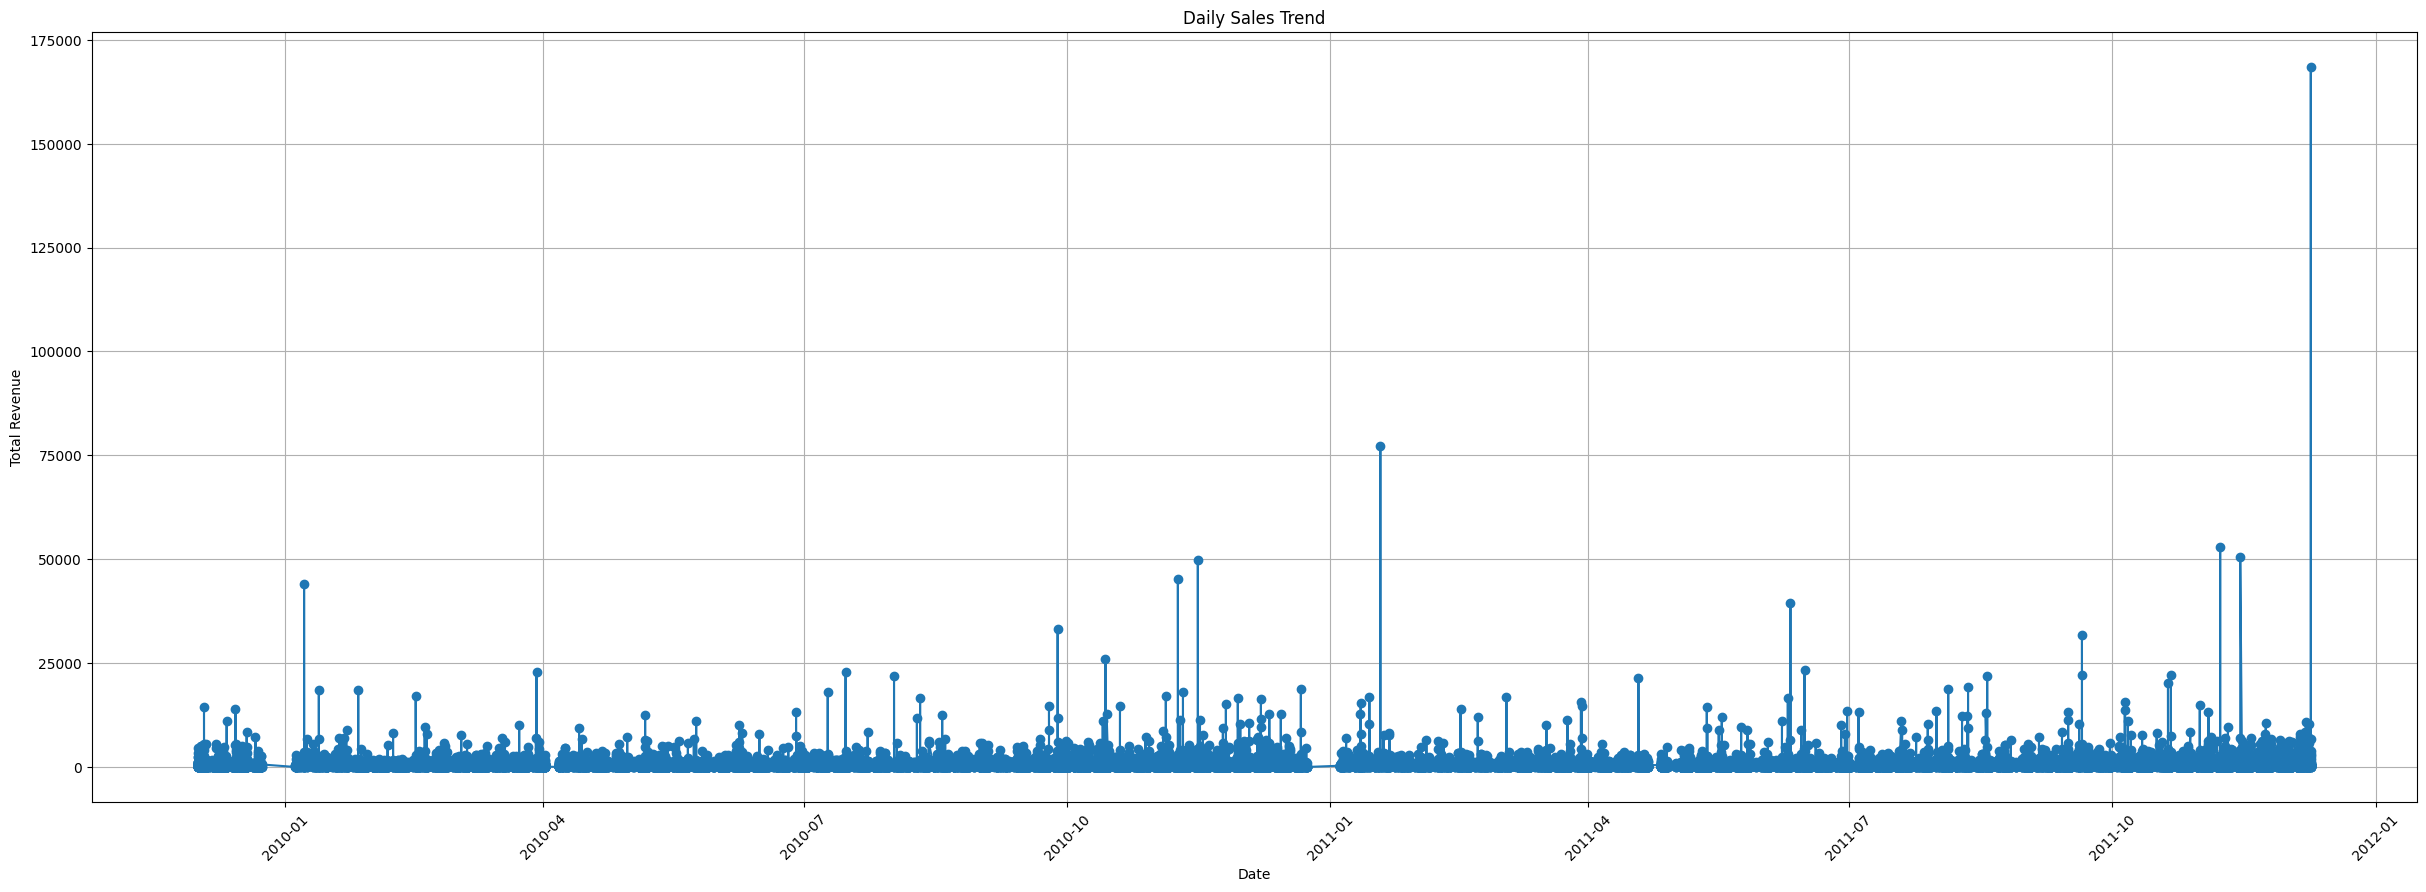

In [ ]:
daily_sales = df_cleaned.groupby('InvoiceDate_Converted')['Revenue'].sum().reset_index()

# Plot daily sales trend
plt.figure(figsize=(30, 10))
plt.plot(daily_sales['InvoiceDate_Converted'], daily_sales['Revenue'], marker='o')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


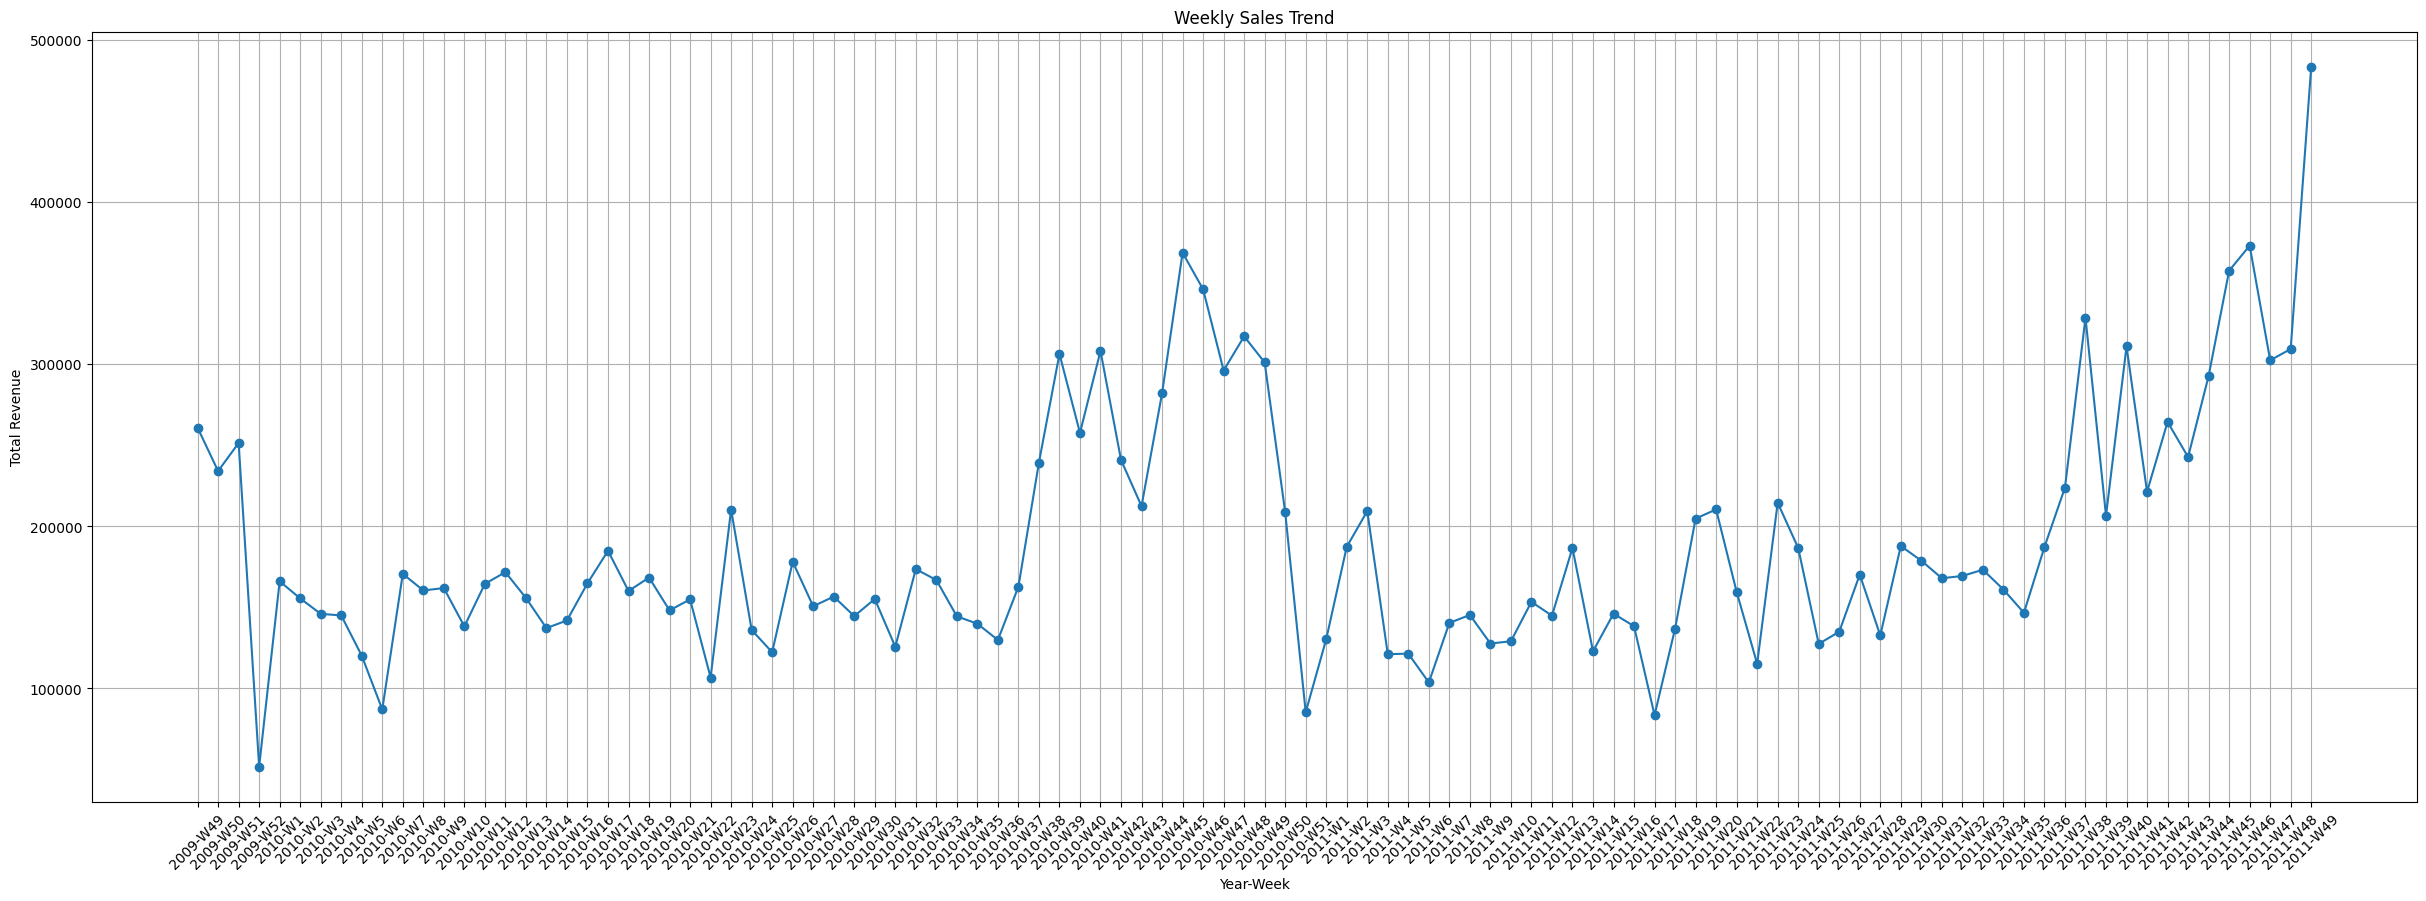

In [ ]:
weekly_sales = df_cleaned.groupby(['Year', 'Week'])['Revenue'].sum().reset_index()
weekly_sales['YearWeek'] = weekly_sales['Year'].astype(str) + '-W' + weekly_sales['Week'].astype(str)

# Plot weekly sales trend
plt.figure(figsize=(30, 10))
plt.plot(weekly_sales['YearWeek'], weekly_sales['Revenue'], marker='o')
plt.title('Weekly Sales Trend')
plt.xlabel('Year-Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


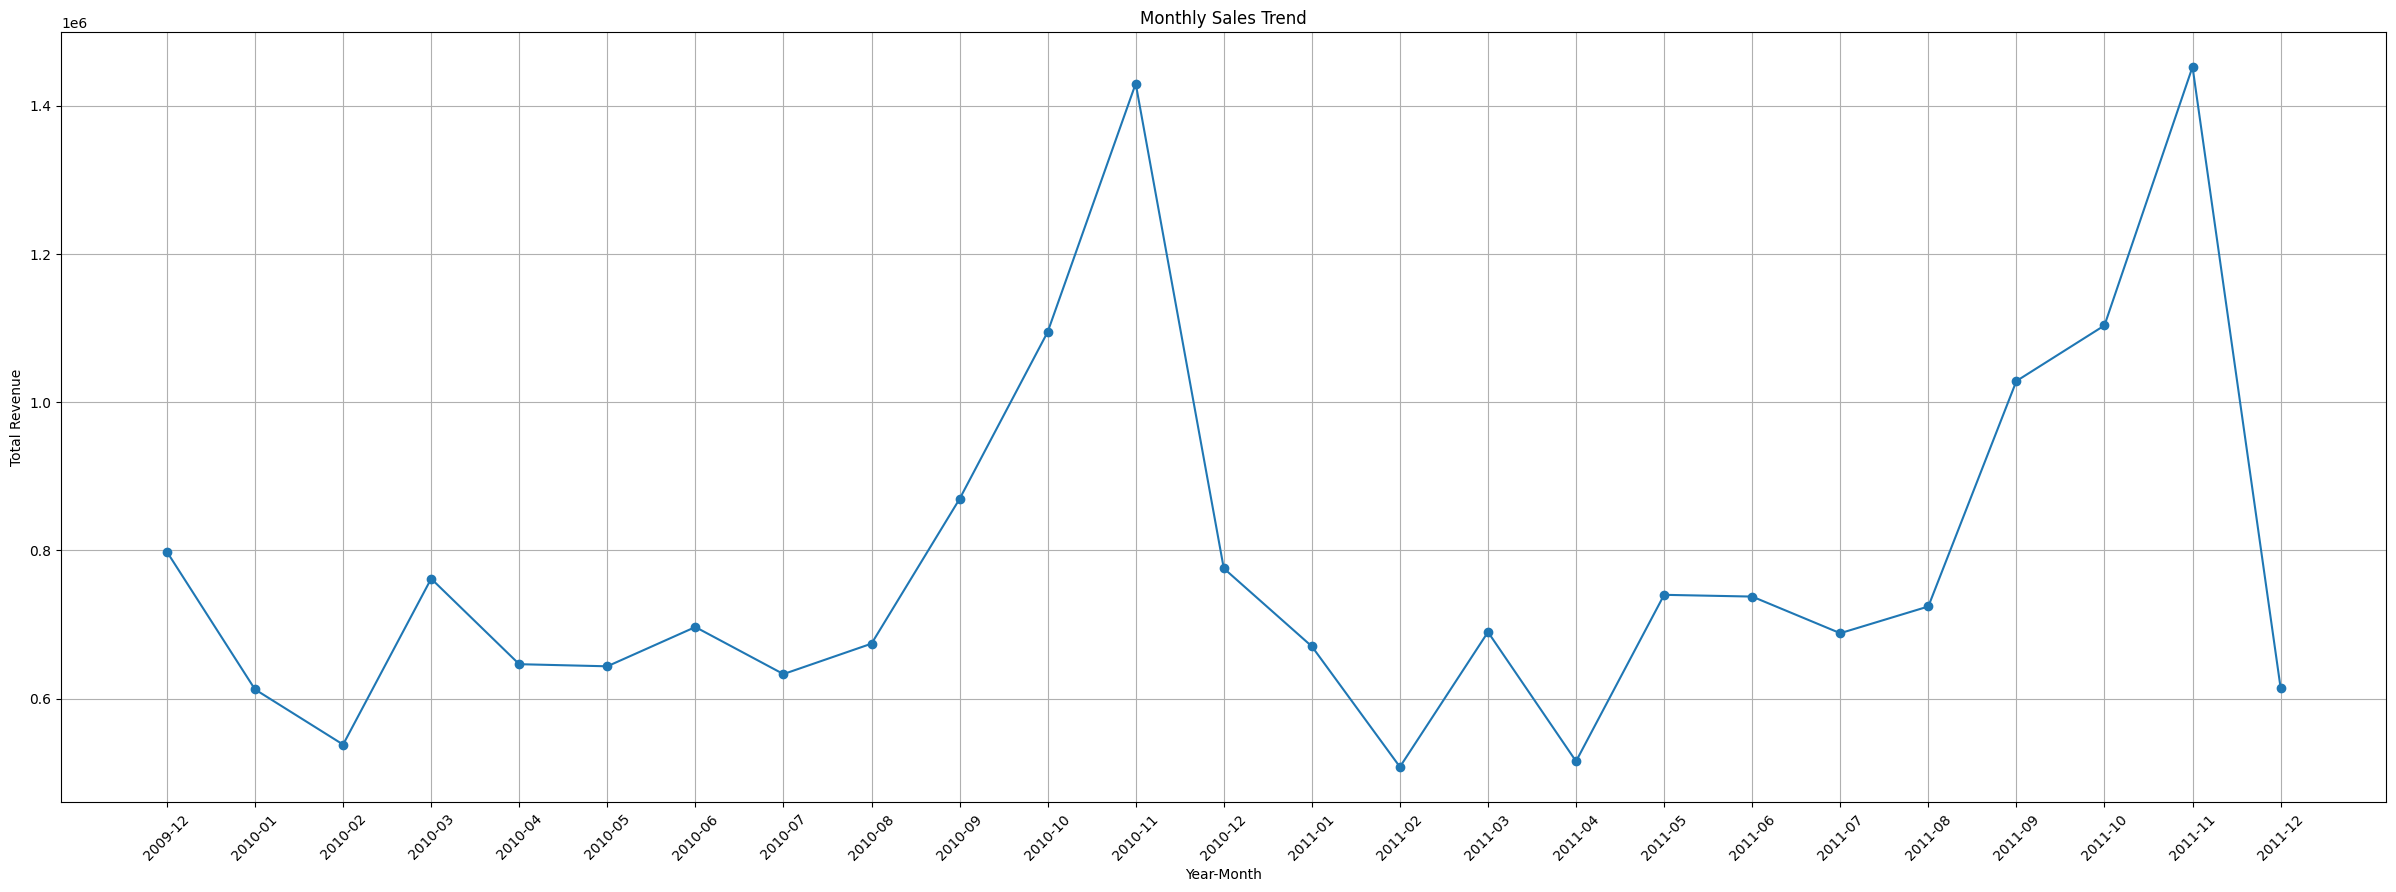

In [ ]:
# Plot monthly sales trends
monthly_sales = df_cleaned.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)
plt.figure(figsize=(30, 10))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Revenue'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
